# TabNet Binary Classification

This notebook implements a complete machine learning pipeline for binary classification of coronary artery stenosis using TabNet, a deep learning architecture specifically designed for tabular data.

## Execution Order:
1. **Imports**: Load all required libraries including pytorch-tabnet
2. **Load Dataset**: Import and prepare the raw data, create binary target
3. **Dropping dependent Features**: Remove derived variables
4. **Preprocessing**: Clean data, handle missing values, and prepare features
5. **Feature Selection**: Select top k features using mutual information
6. **SMOTE Oversampling**: Balance classes using synthetic oversampling
7. **Build and Train TabNet**: Train TabNet classifier with attention-based feature selection
8. **Evaluation**: Comprehensive evaluation metrics
9. **Overfitting Check**: Compare training vs. test performance
10. **Visualization**: ROC and Precision-Recall curves
11. **Feature Importance**: TabNet's interpretable feature attributions
12. **Hyperparameter Optimization** (Optional): Find optimal TabNet parameters


## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **pytorch-tabnet**: TabNet deep learning architecture for tabular data
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import torch
    print("TabNet successfully imported")
except ImportError:
    print("ERROR: pytorch-tabnet not installed. Please install with: pip install pytorch-tabnet")
    raise


TabNet successfully imported


## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Removes features with more than 62.5% missing values
- Removes class 1 (non-significant stenosis) to create binary classification
- Automatically converts object columns that look numeric to appropriate data types
- Displays cleaned dataset shape


In [2]:
na_values = ["", " ", "NA", "N/A", "NULL"]
data = pd.read_csv("../data/T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)

threshold = 0.625
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = True
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)

object_cols = data.select_dtypes(include="object").columns
numeric_like_cols = []
for col in object_cols:
    cleaned = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    if numeric_series.notna().mean() > 0.95:
        data[col] = numeric_series
        numeric_like_cols.append(col)

print(f"Converted {len(numeric_like_cols)} mostly-numeric columns")
print(f"Cleaned dataset shape: {data.shape}")


Converted 6 mostly-numeric columns
Cleaned dataset shape: (1678, 94)


## 3. Dropping dependent Features

This cell removes dependent variables that are directly derived from other features. These features contain redundant information and can cause multicollinearity issues.


In [3]:
columns_to_drop = ["remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol", "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"]
data = data.drop(columns_to_drop, axis=1)


## 4. Preprocessing

This cell performs comprehensive data preprocessing:

**Feature Type Identification:**
- Identifies categorical and numerical features
- Automatically converts object columns that look numeric
- Handles manual categorical feature definitions

**Data Cleaning:**
- Removes highly correlated features (correlation > 0.95) to reduce redundancy
- Creates binary target: 0 = No Stenosis, 1 = Significant Stenosis

**Train/Test Split:**
- Splits data into 80% training and 20% test set
- Uses stratified split to maintain class distribution

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: Median imputation


In [4]:
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"].replace({2: 1})

manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

resolved_categoricals = []
missing_manual = []
for candidate in manual_categorical_candidates:
    match = next((col for col in X.columns if col.lower() == candidate.lower()), None)
    if match:
        resolved_categoricals.append(match)
    else:
        missing_manual.append(candidate)

if missing_manual:
    print(f"Manual categorical columns not found: {missing_manual}")

categorical_features = sorted(dict.fromkeys(resolved_categoricals))

non_cat_object_cols = [
    col for col in X.columns if col not in categorical_features and X[col].dtype == "object"
]
forced_numeric = []
for col in non_cat_object_cols:
    cleaned = (
        X[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    X[col] = converted
    forced_numeric.append(col)
if forced_numeric:
    sample = forced_numeric[:5]
    print(
        f"Forced {len(forced_numeric)} object columns to numeric (sample: {sample})"
    )

numerical_features = [col for col in X.columns if col not in categorical_features]

if categorical_features:
    X[categorical_features] = X[categorical_features].astype(str)

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_pre = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features),
    ]
)

preprocessor.fit(X_train, y_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

from scipy.sparse import issparse
if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

print(f"\nTransformed shapes:")
print(f"  Training: {X_train_transformed.shape}")
print(f"  Test: {X_test_transformed.shape}")


Forced 48 object columns to numeric (sample: ['waist_0', 'WHR_0', 'Lp_a_0', 'insulm0', 'HOMA_Index_IR_0'])
Categorical features: 7
Numerical features: 79
Removing 1 highly correlated features
After cleaning - Numerical: 78, Categorical: 7

Transformed shapes:
  Training: (1342, 96)
  Test: (336, 96)


## 5. Feature Selection

This cell performs feature selection to reduce dimensionality and improve model performance:
- Uses SelectKBest with mutual information to select top k features
- Reduces feature space from transformed features to k most informative features
- Helps prevent overfitting and improves training speed


In [5]:
np.random.seed(42)

K_FEATURES = 50

selector = SelectKBest(mutual_info_classif, k=K_FEATURES)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

selected_features_mask = selector.get_support()

print(f"Feature Selection:")
print(f"  Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")


Feature Selection:
  Selected 50 features out of 96


## 6. SMOTE Oversampling

This cell applies SMOTE to handle class imbalance:
- Creates synthetic samples for the minority class
- Balances the training dataset before model training
- Uses k_neighbors=3 for synthetic sample generation


In [6]:
SMOTE_K_NEIGHBORS = 3

class_counts_before = pd.Series(y_train).value_counts().sort_index()
print(f"Class distribution before SMOTE:")
for cls, count in class_counts_before.items():
    class_name = {0: "No Stenosis", 1: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

smote = SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS, sampling_strategy='auto')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

class_counts_after = pd.Series(y_train_balanced).value_counts().sort_index()
print(f"\nClass distribution after SMOTE:")
for cls, count in class_counts_after.items():
    class_name = {0: "No Stenosis", 1: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train_balanced) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

print(f"\nTraining set size: {X_train_balanced.shape[0]} samples, {X_train_balanced.shape[1]} features")


Class distribution before SMOTE:
  No Stenosis (Class 0): 290 samples (21.6%)
  Significant Stenosis (Class 1): 1052 samples (78.4%)

Class distribution after SMOTE:
  No Stenosis (Class 0): 1052 samples (50.0%)
  Significant Stenosis (Class 1): 1052 samples (50.0%)

Training set size: 2104 samples, 50 features


## 7. Build and Train TabNet Model

This cell builds and trains the TabNet classifier:

**TabNet Architecture:**
- Attention-based feature selection
- Sequential attention for decision steps
- Sparsity regularization through Entmax
- Batch normalization and residual connections

**Hyperparameters:**
- Optimized for binary classification
- Handles class imbalance through class weights
- Regularization to prevent overfitting
- Early stopping based on validation loss


In [7]:
np.random.seed(42)

class_counts = pd.Series(y_train).value_counts().sort_index()
n_samples = len(y_train)
n_classes = len(class_counts)

class_weights = {}
for cls in class_counts.index:
    class_weights[cls] = n_samples / (n_classes * class_counts[cls])

print(f"Class weights: {class_weights}")

tabnet_params = {
    'n_d': 64,
    'n_a': 64,
    'n_steps': 5,
    'gamma': 1.5,
    'lambda_sparse': 1e-3,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {'lr': 2e-2},
    'mask_type': 'entmax',
    'n_shared': 2,
    'n_independent': 2,
    'clip_value': 2.0,
    'verbose': 1,
    'seed': 42,
    'device_name': 'cpu'
}

tabnet = TabNetClassifier(**tabnet_params)

print(f"\nTabNet Configuration:")
print(f"  Decision dimension (n_d): {tabnet_params['n_d']}")
print(f"  Attention dimension (n_a): {tabnet_params['n_a']}")
print(f"  Decision steps (n_steps): {tabnet_params['n_steps']}")
print(f"  Sparsity regularization: {tabnet_params['lambda_sparse']}")
print(f"  Learning rate: {tabnet_params['optimizer_params']['lr']}")

print(f"\nTraining TabNet model...")

tabnet.fit(
    X_train=X_train_balanced,
    y_train=y_train_balanced,
    eval_set=[(X_train_selected, y_train)],
    eval_name=['train'],
    eval_metric=['logloss'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

print(f"\nModel training completed!")


Class weights: {0: np.float64(2.3137931034482757), 1: np.float64(0.6378326996197718)}

TabNet Configuration:
  Decision dimension (n_d): 64
  Attention dimension (n_a): 64
  Decision steps (n_steps): 5
  Sparsity regularization: 0.001
  Learning rate: 0.02

Training TabNet model...
epoch 0  | loss: 1.31181 | train_logloss: 5.12841 |  0:00:00s
epoch 1  | loss: 1.14659 | train_logloss: 4.0451  |  0:00:00s
epoch 2  | loss: 1.00172 | train_logloss: 3.45057 |  0:00:01s
epoch 3  | loss: 0.95425 | train_logloss: 2.20865 |  0:00:01s
epoch 4  | loss: 0.88437 | train_logloss: 9.66122 |  0:00:02s
epoch 5  | loss: 0.76732 | train_logloss: 11.03172|  0:00:02s
epoch 6  | loss: 0.77484 | train_logloss: 1.87112 |  0:00:02s
epoch 7  | loss: 0.73399 | train_logloss: 3.26563 |  0:00:03s
epoch 8  | loss: 0.65636 | train_logloss: 3.09562 |  0:00:03s
epoch 9  | loss: 0.64787 | train_logloss: 2.8263  |  0:00:04s
epoch 10 | loss: 0.6465  | train_logloss: 3.06897 |  0:00:04s
epoch 11 | loss: 0.61324 | train_lo

MODEL EVALUATION

Overall Accuracy: 0.7708
Balanced Accuracy: 0.6458
F1 Score: 0.8555

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.47      0.42      0.45        73
Significant Stenosis       0.84      0.87      0.86       263

            accuracy                           0.77       336
           macro avg       0.66      0.65      0.65       336
        weighted avg       0.76      0.77      0.77       336


Confusion Matrix:


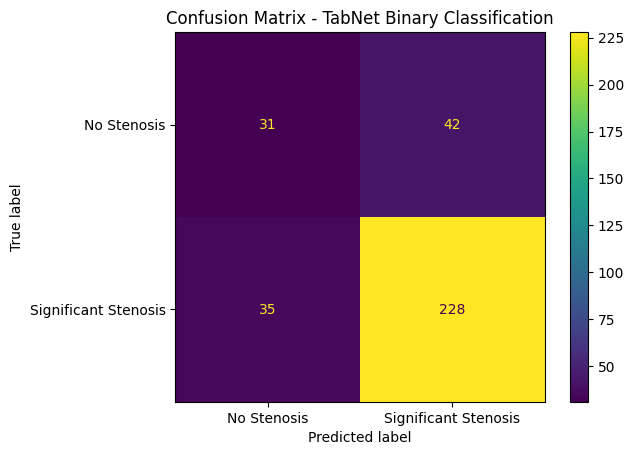


Per-Class Recall:
  No Stenosis (Class 0): 0.4247
  Significant Stenosis (Class 1): 0.8669


In [8]:
y_pred = tabnet.predict(X_test_selected)
y_proba = tabnet.predict_proba(X_test_selected)

print("=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

accuracy = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\n" + "=" * 80)
print("Classification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=["No Stenosis", "Significant Stenosis"]))

print("\n" + "=" * 80)
print("Confusion Matrix:")
print("=" * 80)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Stenosis", "Significant Stenosis"]).plot()
plt.title("Confusion Matrix - TabNet Binary Classification")
plt.show()

recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]
recall_class0 = recall_score(y_test, y_pred, labels=[0], average=None)[0]

print(f"\nPer-Class Recall:")
print(f"  No Stenosis (Class 0): {recall_class0:.4f}")
print(f"  Significant Stenosis (Class 1): {recall_class1:.4f}")


## 9. Overfitting Check

This cell compares training and test set performance to detect overfitting:
- Calculates metrics on both training and test sets
- Compares balanced accuracy, recall, and overall accuracy
- Identifies performance gaps that indicate overfitting
- Helps validate model generalization


In [9]:
y_pred_train = tabnet.predict(X_train_selected)

train_recall_class1 = recall_score(y_train, y_pred_train, labels=[1], average=None)[0]
test_recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]

train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\nRecall (Significant Stenosis - Class 1):")
print(f"  Training: {train_recall_class1:.4f}")
print(f"  Test:     {test_recall_class1:.4f}")
print(f"  Gap:      {train_recall_class1 - test_recall_class1:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

gap_recall = train_recall_class1 - test_recall_class1
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("Model shows good generalization (small gap between train/test)")
    print(f"  Recall gap (Class 1): {gap_recall:.4f} (good)")
    print(f"  Balanced accuracy gap: {gap_bal:.4f} (good)")


OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)

Recall (Significant Stenosis - Class 1):
  Training: 0.9049
  Test:     0.8669
  Gap:      0.0380

Balanced Accuracy:
  Training: 0.6645
  Test:     0.6458
  Gap:      0.0188

Regular Accuracy:
  Training: 0.8010
  Test:     0.7708
  Gap:      0.0302

Model shows good generalization (small gap between train/test)
  Recall gap (Class 1): 0.0380 (good)
  Balanced accuracy gap: 0.0188 (good)


## 10. Visualization: ROC and Precision-Recall Curves

This cell visualizes model performance with binary ROC and Precision-Recall curves:
- Plots ROC curve showing True Positive Rate vs. False Positive Rate
- Plots Precision-Recall curve showing Precision vs. Recall
- Shows AUC and Average Precision metrics
- Provides visual assessment of model performance


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1])
avg_precision = average_precision_score(y_test, y_proba[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — TabNet Binary Classification')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(recall, precision, lw=2, label=f'AP = {avg_precision:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — TabNet Binary Classification')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")


## 11. TabNet Feature Importance

This cell visualizes TabNet's interpretable feature attributions:
- TabNet provides feature importance through attention mechanisms
- Shows which features are most important for predictions
- Provides interpretability unique to TabNet architecture
- Plots top 15 most important features


In [ ]:
feature_importances = tabnet.feature_importances_
selected_feature_names = preprocessor.get_feature_names_out()[selected_features_mask]

importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features (TabNet Attention-based):")
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - TabNet Binary Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 12. Hyperparameter Optimization (Optional)

This cell performs hyperparameter optimization for TabNet:
- Tests different combinations of TabNet hyperparameters
- Uses cross-validation to evaluate parameter combinations
- Finds optimal hyperparameters for the TabNet classifier
- Can be skipped if using default parameters

**Note:** TabNet hyperparameter optimization can be computationally expensive. Consider using a smaller search space or fewer epochs for faster results.


In [ ]:
optimize_hyperparameters = False

if optimize_hyperparameters:
    param_combinations = [
        {'n_d': 32, 'n_a': 32, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-3},
        {'n_d': 64, 'n_a': 64, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 1e-3},
        {'n_d': 64, 'n_a': 64, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 5e-4},
        {'n_d': 128, 'n_a': 128, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 1e-3},
    ]
    
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    results = []
    
    print("Testing different TabNet hyperparameter combinations...")
    print("=" * 60)
    
    for i, params in enumerate(param_combinations):
        print(f"\nCombination {i+1}/{len(param_combinations)}: {params}")
        
        tabnet_params_test = {
            'n_d': params['n_d'],
            'n_a': params['n_a'],
            'n_steps': params['n_steps'],
            'gamma': params['gamma'],
            'lambda_sparse': params['lambda_sparse'],
            'optimizer_fn': torch.optim.Adam,
            'optimizer_params': {'lr': 2e-2},
            'mask_type': 'entmax',
            'n_shared': 2,
            'n_independent': 2,
            'clip_value': 2.0,
            'verbose': 0,
            'seed': 42,
            'device_name': 'cpu'
        }
        
        cv_scores = []
        
        for train_idx, val_idx in cv_strategy.split(X_train_selected, y_train):
            X_train_cv, X_val_cv = X_train_selected[train_idx], X_train_selected[val_idx]
            y_train_cv, y_val_cv = y_train[train_idx], y_train[val_idx]
            
            X_train_cv_balanced, y_train_cv_balanced = smote.fit_resample(X_train_cv, y_train_cv)
            
            tabnet_cv = TabNetClassifier(**tabnet_params_test)
            tabnet_cv.fit(
                X_train=X_train_cv_balanced,
                y_train=y_train_cv_balanced,
                eval_set=[(X_val_cv, y_val_cv)],
                eval_name=['val'],
                eval_metric=['logloss'],
                max_epochs=100,
                patience=10,
                batch_size=1024,
                virtual_batch_size=128,
                num_workers=0,
                drop_last=False,
                verbose=0
            )
            
            y_pred_cv = tabnet_cv.predict(X_val_cv)
            cv_scores.append(balanced_accuracy_score(y_val_cv, y_pred_cv))
        
        mean_score = np.mean(cv_scores)
        std_score = np.std(cv_scores)
        results.append({
            'params': params,
            'cv_mean': mean_score,
            'cv_std': std_score
        })
        
        print(f"CV Balanced Accuracy: {mean_score:.4f} (+/- {std_score*2:.4f})")
    
    results_df = pd.DataFrame(results)
    best_idx = results_df['cv_mean'].idxmax()
    best_params = results_df.loc[best_idx, 'params']
    best_score = results_df.loc[best_idx, 'cv_mean']
    
    print("\n" + "=" * 60)
    print(f"Best parameters: {best_params}")
    print(f"Best CV Balanced Accuracy: {best_score:.4f}")
    print(f"\nRecommendation: Consider using these parameters for improved performance")
else:
    print("Hyperparameter Optimization skipped. Using default parameters.")
